(interventional_what_if_do_operator)=
# Interventional what-if analysis using the PyMC do-operator

:::{post} August, 2023
:tags: causal inference, do-operator, interventional analysis
:category: beginner, reference
:author: Shekhar Khandelwal
:::

In [1]:
import warnings

import arviz as az
import numpy as np
import pandas as pd
import pymc as pm

warnings.filterwarnings("ignore")

In [2]:
%config InlineBackend.figure_format = "retina"
az.style.use("arviz-variat")
rng = np.random.default_rng(42)
SEED = 8927

## Introduction

In the realm of data science and analytics, understanding the causal relationships between variables is paramount. While traditional statistical methods have provided insights into these relationships, the advent of probabilistic programming has ushered in a new era of causal analysis. In this article, we will explore the power of interventional what-if analysis using the PyMC framework, with a special focus on the `do`-operator.

The `do`-operator lets us answer interventional "what-if" questions: *What would happen to the outcome if we forced a variable to a specific value?* By leveraging `pm.do`, we can programmatically simulate these scenarios, giving us a deeper understanding of the causal relationships between predictors and target variables.

Through a step-by-step guide, we will delve into the process of building a PyMC model skeleton, generating data using the `do`-operator, and validating the relationships captured by the model. Furthermore, we will explore how the `do`-operator can simulate different what-if scenarios, akin to programmatic A/B testing.

:::{admonition} Interventions vs. counterfactuals: where does this notebook sit on the causal ladder?
:class: important

Pearl's *causal ladder* distinguishes three levels of causal reasoning:

- **L1 — Association (seeing)**: What do we observe? $P(Y \mid X)$
- **L2 — Intervention (doing)**: What happens if we force a variable to a value? $P(Y \mid \operatorname{do}(X = x))$
- **L3 — Counterfactual (imagining)**: What *would have happened* to *this specific unit* under a different action, given what we already observed? $Y_x \mid X = x', Y = y'$

`pm.do` directly supports **L2 queries**. This notebook demonstrates interventional what-if analysis — we set a variable to a new value and predict the outcome. True unit-level counterfactuals (L3) require an additional **abduction** step: inferring unit-specific exogenous terms ($U$) from observed evidence before predicting in the intervened world. That step is not demonstrated here.

For readers interested in L3 counterfactual reasoning, see Pearl, Glymour & Jewell (2016), *Causal Inference in Statistics: A Primer*, Sections 4.2.3–4.2.4.

## Steps

The basic workflow for interventional what-if analysis using the `do`-operator in PyMC can be summarized in the following steps:

- Step 1. Build a PyMC model skeleton
- Step 2. Use model skeleton and generate data using `do`-operator to infuse relationship between predictors and target variable
- Step 3. Use `observe`-operator to assign generated data on the model skeleton
- Step 4. Create samples and validate that the infused relationship between predictors and target variable are captured by the model samples
- Step 5. Use `do`-operator to generate target variable with different what-if scenarios (programmatic A/B testing)

### Step 1. Build a pymc model skeleton

For this demo, we are building a very simple Linear Regression model.
- Predictor — ‘a’, ‘b’, ‘c’
- Target Variable — ‘y’
- Coefficients —
>- ‘beta_ay’ -> coefficient of |a|
>- ‘beta_by’ -> coefficient of |b|
>- ‘beta_cy’ -> coefficient of |c|

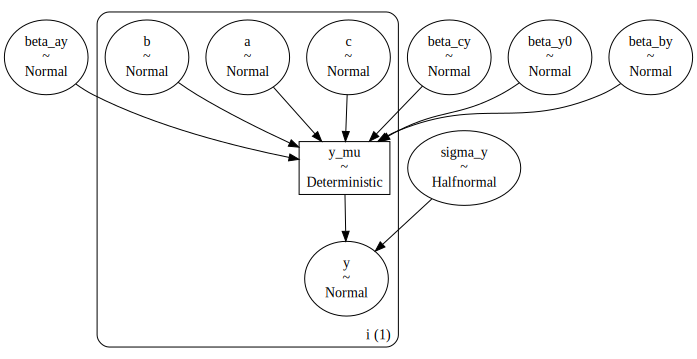

In [3]:
with pm.Model(coords={"i": [0]}) as model_generative:
    # priors
    beta_y0 = pm.Normal("beta_y0")
    beta_ay = pm.Normal("beta_ay")
    beta_by = pm.Normal("beta_by")
    beta_cy = pm.Normal("beta_cy")
    # observation noise on Y
    sigma_y = pm.HalfNormal("sigma_y")
    # core nodes and causal relationships
    a = pm.Normal("a", mu=0, sigma=1, dims="i")
    b = pm.Normal("b", mu=0, sigma=1, dims="i")
    c = pm.Normal("c", mu=0, sigma=1, dims="i")
    y_mu = pm.Deterministic(
        "y_mu", beta_y0 + (beta_ay * a) + (beta_by * b) + (beta_cy * c), dims="i"
    )
    y = pm.Normal("y", mu=y_mu, sigma=sigma_y, dims="i")


pm.model_to_graphviz(model_generative)

### Step 2. Use model skeleton and generate data using do-operator to infuse relationship between predictors and target variable. We will use this generated data for modelling later.

Let’s first define the predictors relationship with target variable.

In [4]:
true_values = {
    "beta_ay": 1.5,
    "beta_by": 0.7,
    "beta_cy": 0.3,
    "sigma_y": 0.2,
    "beta_y0": 0.0,
}

Basically what we are saying here is, we are intentionally defining the coefficient values, which we expect predictive model to predict later on.

Now the magic begins. We will use do-operator to use this dictionary and sample data variables. How do we do this ? Simple by passing two arguments to pymc do-operator. First, the model skeleton object. And second, the coefficient dictionary.

In [5]:
model_simulate = pm.do(model_generative, true_values)

This will create a new model object with the coefficent variables values infused. 

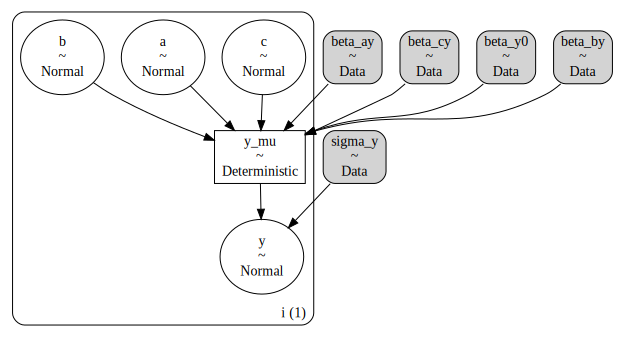

In [6]:
model_simulate.to_graphviz()

The gray shades on the coefficient variables depicts the tale. Check the previous model graph, it was all white.

Now, all we have to do is generate samples, the known pymc way.

Lets generate 100 samples.

In [7]:
N = 100

with model_simulate:
    simulate = pm.sample_prior_predictive(draws=N)

Sampling: [a, b, c, y]


We know that this generates an ArviZ object, and since we have called sample_prior_predictive, hence the object will only contain priors.

In [8]:
simulate

<xarray.DataTree>
Group: /
├── Group: /prior
│       Dimensions:  (chain: 1, draw: 100, i: 1)
│       Coordinates:
│         * chain    (chain) int64 8B 0
│         * draw     (draw) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
│         * i        (i) int64 8B 0
│       Data variables:
│           c        (chain, draw, i) float64 800B -0.3628 0.01986 ... 0.1027 -1.454
│           a        (chain, draw, i) float64 800B 0.5109 -0.7346 ... 0.3652 -0.9545
│           y_mu     (chain, draw, i) float64 800B -0.2609 -1.474 ... 0.6533 -0.2466
│           y        (chain, draw, i) float64 800B -0.3069 -1.163 ... 0.6771 -0.3757
│           b        (chain, draw, i) float64 800B -1.312 -0.5398 ... 0.1067 2.316
│       Attributes:
│           created_at:                 2026-05-04T06:01:17.351008+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.1dev0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  5.28.0+58.gf58491a3
│           sample_dims:                ['chain', 'draw']
├── Group: /prior_predictive
│       Attributes:
│           created_at:                 2026-05-04T06:01:17.352466+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.1dev0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  5.28.0+58.gf58491a3
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Attributes:
│           created_at:                 2026-05-04T06:01:17.352929+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.1dev0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  5.28.0+58.gf58491a3
│           sample_dims:                []
└── Group: /constant_data
        Dimensions:  ()
        Data variables:
            beta_cy  float64 8B 0.3
            beta_by  float64 8B 0.7
            beta_ay  float64 8B 1.5
            beta_y0  float64 8B 0.0
            sigma_y  float64 8B 0.2
        Attributes:
            created_at:                 2026-05-04T06:01:17.353505+00:00
            creation_library:           ArviZ
            creation_library_version:   1.1.1dev0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  5.28.0+58.gf58491a3
            sample_dims:                []

Extract the sampled prior data into a pandas dataframe.

In [9]:
observed = {
    "a": simulate.prior["a"].values.flatten(),
    "b": simulate.prior["b"].values.flatten(),
    "c": simulate.prior["c"].values.flatten(),
    "y": simulate.prior["y"].values.flatten(),
}

df = pd.DataFrame(observed)
print(df.shape)
df.head(5)

(100, 4)


,a,b,c,y
0,0.510869,-1.311934,-0.362795,-0.306949
1,-0.734647,-0.539776,0.019862,-1.162661
2,-0.358604,0.343649,-0.093558,-0.278148
3,-0.251229,-1.154599,-0.542470,-1.489163
4,-1.316097,0.114966,-0.264377,-2.143315


Ok, so now we are all set with a sample data.

### Step 3. Use observe-operator to assign generated data on the model skeleton

Now, this is another cool feature of pymc newly introduced observe method. Observe method, takes in a model skeleton and the dictionary with the data for the variables we want to infuse into the model.

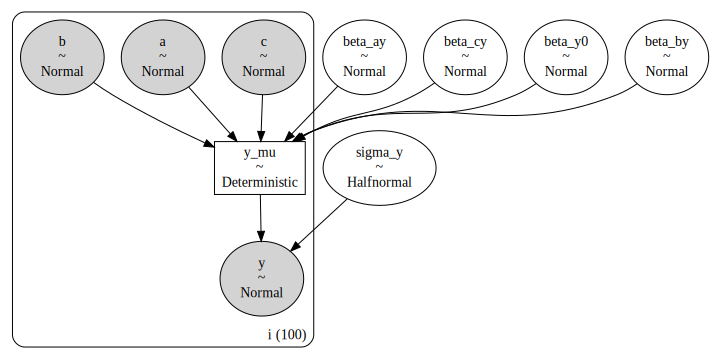

In [10]:
data_dict = {"a": df["a"], "b": df["b"], "c": df["c"], "y": df["y"]}
model_inference = pm.observe(model_generative, data_dict)
model_inference.set_dim("i", N, coord_values=np.arange(N))
pm.model_to_graphviz(model_inference)

See the gray matter again. This time we have observed data infused into the model, and we have to sample for the coefficient and other parameters.

So, lets sample.

### Step 4. Create samples and validate that the infused relationship between predictors and target variable are captured by the model samples

In [11]:
with model_inference:
    idata = pm.sample(random_seed=SEED)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_cy, beta_by, beta_ay, beta_y0, sigma_y]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


Now, lets validate if model captured the infused coefficient values in the data.

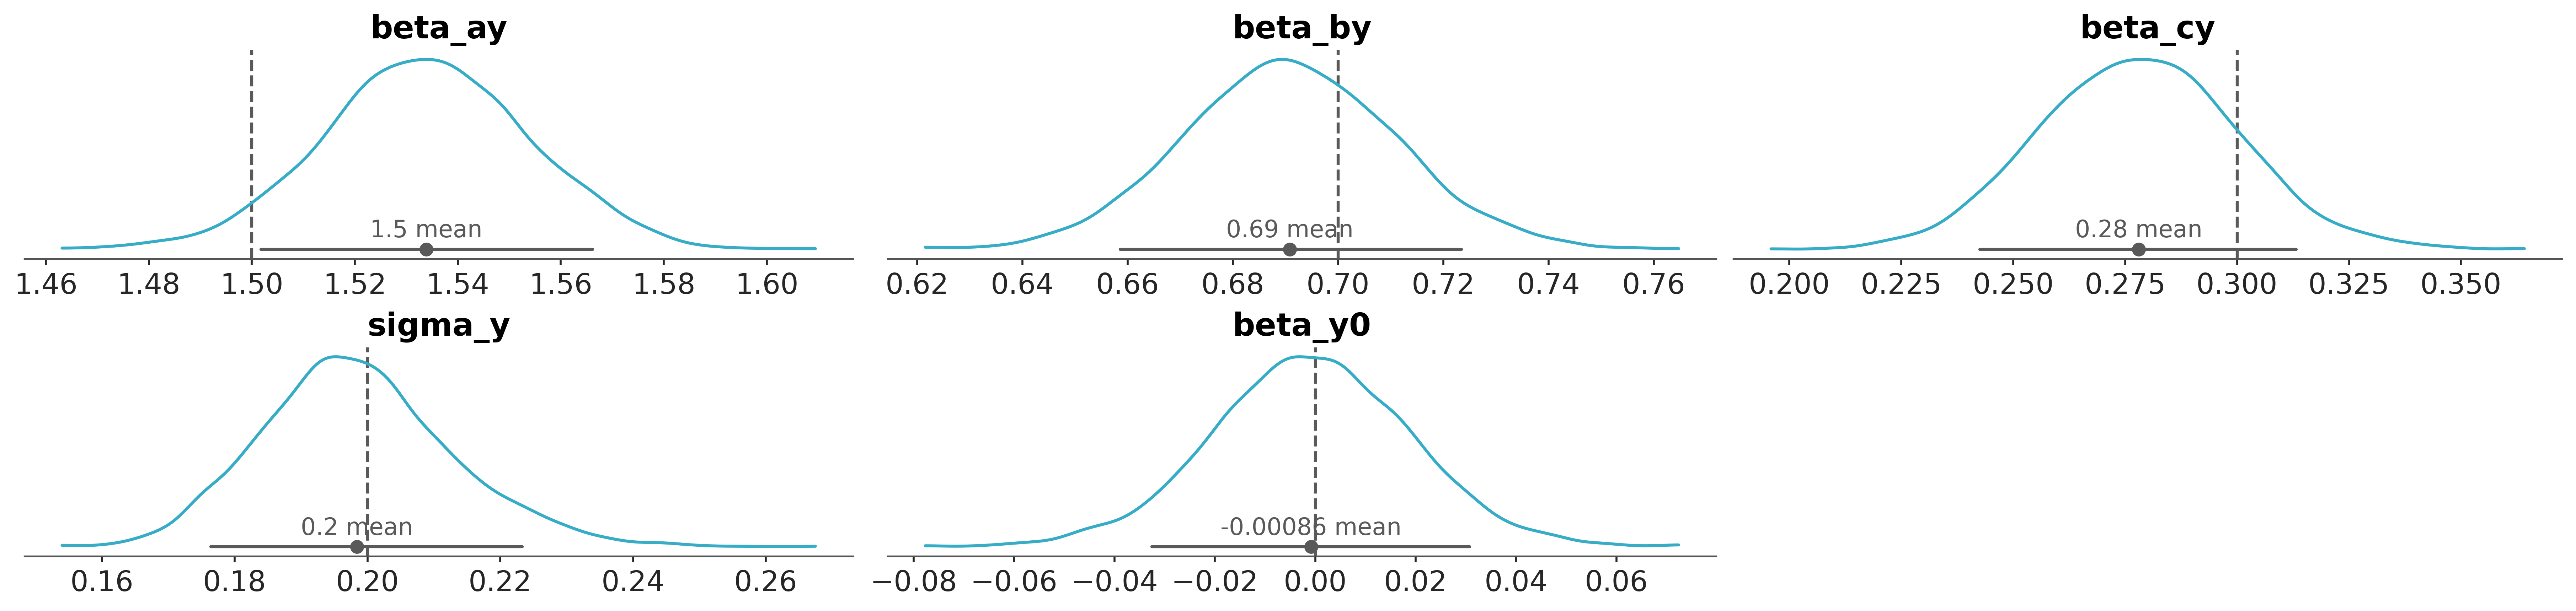

In [12]:
pc = az.plot_dist(
    idata,
    var_names=list(true_values.keys()),
    col_wrap=3,
)
az.add_lines(pc, true_values);

Pretty nice fit!

Now we can use the `do`-operator for interventional what-if analysis: generating predictions for the target variable under different hypothetical settings of the predictors.

_What if all values of `b` were 0?_

_What if all values of `b` were doubled?_

Here's how.

### Step 5. Use `do`-operator to generate target variable with different what-if scenarios
Since we want to experiment with `b`, let's first assign observed values to `a` and `c`. Not to `y`, because that's what we want to sample.

In [13]:
model_counterfactual = pm.do(model_inference, {"a": df["a"], "c": df["c"]})

Now, let’s begin the fun part — generating what-if predictions.

### _Scenario 1 :- What if all values for 'b' were 0 ?_

In [14]:
model_b0 = pm.do(model_counterfactual, {"b": np.zeros(N, dtype="int32")}, prune_vars=True)
model_b1 = pm.do(model_counterfactual, {"b": df["b"]}, prune_vars=True)

Just sample.

In [15]:
# Sample when 'b' was 0: P(y | (a,c), do(b=0))
idata_b0 = pm.sample_posterior_predictive(
    idata,
    model=model_b0,
    predictions=True,
    var_names=["y_mu"],
    random_seed=SEED,
)
# Sample when 'b' was as observed: P(y | (a,c), do(b=observed))
idata_b1 = pm.sample_posterior_predictive(
    idata,
    model=model_b1,
    predictions=True,
    var_names=["y_mu"],
    random_seed=SEED,
)

Sampling: []


Output()

Sampling: []


Output()

Some basic Python and here we have the what-if predictions.

In [16]:
df["b_scenario_1"] = 0
df["y_scenario_1"] = (
    idata_b0.predictions.y_mu.mean(("chain", "draw")).values.reshape(1, -1).flatten()
)
df.head(5)

,a,b,c,y,b_scenario_1,y_scenario_1
0,0.510869,-1.311934,-0.362795,-0.306949,0,0.681877
1,-0.734647,-0.539776,0.019862,-1.162661,0,-1.122175
2,-0.358604,0.343649,-0.093558,-0.278148,0,-0.576914
3,-0.251229,-1.154599,-0.542470,-1.489163,0,-0.537017
4,-1.316097,0.114966,-0.264377,-2.143315,0,-2.093052


### _Scenario 2: What if ‘b’ was 5 times as observed_

In [17]:
model_b0 = pm.do(model_counterfactual, {"b": 5 * df["b"]}, prune_vars=True)
model_b1 = pm.do(model_counterfactual, {"b": df["b"]}, prune_vars=True)

Sample.

In [18]:
# Sample when 'b' was 5 times b: P(y | (a,c), do(b=5*b))
idata_b0 = pm.sample_posterior_predictive(
    idata,
    model=model_b0,
    predictions=True,
    var_names=["y_mu"],
    random_seed=SEED,
)
# Sample when 'b' was as observed: P(y | (a,c), do(b=observed))
idata_b1 = pm.sample_posterior_predictive(
    idata,
    model=model_b1,
    predictions=True,
    var_names=["y_mu"],
    random_seed=SEED,
)

df["b_scenario_2"] = 5 * df["b"]
df["y_scenario_2"] = (
    idata_b0.predictions.y_mu.mean(("chain", "draw")).values.reshape(1, -1).flatten()
)
df.head(5)

Sampling: []


Output()

Sampling: []


Output()

,a,b,c,y,b_scenario_1,y_scenario_1,b_scenario_2,y_scenario_2
0,0.510869,-1.311934,-0.362795,-0.306949,0,0.681877,-6.559670,-3.849755
1,-0.734647,-0.539776,0.019862,-1.162661,0,-1.122175,-2.698878,-2.986647
2,-0.358604,0.343649,-0.093558,-0.278148,0,-0.576914,1.718247,0.610107
3,-0.251229,-1.154599,-0.542470,-1.489163,0,-0.537017,-5.772996,-4.525190
4,-1.316097,0.114966,-0.264377,-2.143315,0,-2.093052,0.574829,-1.695942


Now you've got the idea. It's an open playground — intervene on whichever variable you like and see how the predicted outcome changes.

This opens the door for many possibilities in causal analytics: comparing treatment policies, sensitivity checks, and programmatic A/B testing.

## Authors
- Authored by [Shekhar Khandelwal](https://github.com/shekharkhandelwal1983) in August 2023
- Updated by Osvaldo Martin in February 2026
- Updated by Osvaldo Martin in April 2026
- Revised wording around interventions and counterfactuals, by [Benjamin T. Vincent](https://github.com/drbenvincent) in March 2026

## References

- Pearl, J., Glymour, M., & Jewell, N. P. (2016). *Causal Inference in Statistics: A Primer*. Wiley. Sections 4.2.3–4.2.4.
- Khandelwal, S. (2023). [Counterfactuals for Causal Analysis via PyMC Do-Operator](https://medium.com/@khandelwal-shekhar/counterfactuals-for-causal-analysis-via-pymc-do-operator-234ba04e4e80). Medium.
- PyMC Labs. [Causal Analysis with PyMC: Answering "What If" with the New Do-Operator](https://www.pymc-labs.io/blog-posts/causal-analysis-with-pymc-answering-what-if-with-the-new-do-operator/).

## Watermark

In [19]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor

Last updated: Mon, 04 May 2026

Python implementation: CPython
Python version       : 3.14.4
IPython version      : 9.12.0

pytensor: 2.38.0+158.gb3cfb34cb

arviz : 1.1.0
numpy : 2.4.4
pandas: 3.0.2
pymc  : 5.28.0+58.gf58491a3

Watermark: 2.6.0



:::{include} ../page_footer.md
:::